In [1]:
import pandas as pd
import numpy as np
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
df = pd.read_csv("tweet_emotions.csv")

In [3]:
df.head()

,tweet_id,sentiment,content
0,1956967341,empty,@tiffanylue i know i was listenin to bad habi...
1,1956967666,sadness,Layin n bed with a headache ughhhh...waitin o...
2,1956967696,sadness,Funeral ceremony...gloomy friday...
3,1956967789,enthusiasm,wants to hang out with friends SOON!
4,1956968416,neutral,@dannycastillo We want to trade with someone w...


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   tweet_id   40000 non-null  int64 
 1   sentiment  40000 non-null  object
 2   content    40000 non-null  object
dtypes: int64(1), object(2)
memory usage: 937.6+ KB


In [5]:
df['sentiment'].value_counts()

sentiment
neutral       8638
worry         8459
happiness     5209
sadness       5165
love          3842
surprise      2187
fun           1776
relief        1526
hate          1323
empty          827
enthusiasm     759
boredom        179
anger          110
Name: count, dtype: int64

In [6]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\arghaanjahangir\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\arghaanjahangir\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [7]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):

    # lowercase
    text = text.lower()

    # remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # remove usernames
    text = re.sub(r'@\w+', '', text)

    # remove hashtags
    text = re.sub(r'#\w+', '', text)

    # remove numbers
    text = re.sub(r'\d+', '', text)

    # remove special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # tokenization
    words = text.split()

    # remove stopwords + lemmatization
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]

    return " ".join(words)

In [8]:
df['clean_text'] = df['content'].apply(clean_text)

In [9]:
df[['content', 'clean_text']].head()

,content,clean_text
0,@tiffanylue i know i was listenin to bad habi...,know listenin bad habit earlier started freaki...
1,Layin n bed with a headache ughhhh...waitin o...,layin n bed headache ughhhhwaitin call
2,Funeral ceremony...gloomy friday...,funeral ceremonygloomy friday
3,wants to hang out with friends SOON!,want hang friend soon
4,@dannycastillo We want to trade with someone w...,want trade someone houston ticket one


In [10]:
df.drop_duplicates(inplace=True)

print("Dataset shape after removing duplicates:")
print(df.shape)

Dataset shape after removing duplicates:
(40000, 4)


In [11]:
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['clean_text'])

y = df['sentiment']

In [12]:
print(X.shape)

(40000, 5000)


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [14]:
print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (32000, 5000)
Testing Data: (8000, 5000)


In [15]:
nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [16]:
nb_pred = nb_model.predict(X_test)

In [17]:
print("Naive Bayes Accuracy:")
print(accuracy_score(y_test, nb_pred))

Naive Bayes Accuracy:
0.317625


In [18]:
print(classification_report(y_test, nb_pred))

              precision    recall  f1-score   support

       anger       0.00      0.00      0.00        19
     boredom       0.00      0.00      0.00        31
       empty       0.00      0.00      0.00       162
  enthusiasm       0.00      0.00      0.00       163
         fun       0.00      0.00      0.00       338
   happiness       0.36      0.27      0.31      1028
        hate       0.00      0.00      0.00       268
        love       0.54      0.27      0.36       762
     neutral       0.30      0.56      0.39      1740
      relief       0.00      0.00      0.00       352
     sadness       0.35      0.11      0.17      1046
    surprise       0.67      0.00      0.01       425
       worry       0.29      0.58      0.39      1666

    accuracy                           0.32      8000
   macro avg       0.19      0.14      0.13      8000
weighted avg       0.31      0.32      0.26      8000



C:\Users\arghaanjahangir\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\arghaanjahangir\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\arghaanjahangir\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0]

In [19]:
print(confusion_matrix(y_test, nb_pred))

[[  0   0   0   0   0   1   0   0   4   0   1   0  13]
 [  0   0   0   0   0   0   0   2   9   0   1   0  19]
 [  0   0   0   0   0   7   0   2  89   0   6   0  58]
 [  0   0   0   0   0  17   0   3  84   0   5   0  54]
 [  0   0   0   0   0  59   0  14 153   0   6   0 106]
 [  0   0   0   0   0 281   0  69 431   0  17   0 230]
 [  0   0   0   0   0   3   0   0  69   0  27   0 169]
 [  0   0   0   0   0 136   0 205 242   0  18   0 161]
 [  0   0   0   0   0  95   0  36 970   0  40   0 599]
 [  0   0   0   0   0  47   0  10 160   0   6   0 129]
 [  0   0   0   0   0  31   0   6 300   0 115   0 594]
 [  0   0   0   0   0  51   0  10 168   0  11   2 183]
 [  0   0   0   0   0  62   0  26 536   0  73   1 968]]


In [20]:
svm_model = LinearSVC()

svm_model.fit(X_train, y_train)

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,None


In [21]:
svm_pred = svm_model.predict(X_test)

In [22]:
print("SVM Accuracy:")
print(accuracy_score(y_test, svm_pred))

SVM Accuracy:
0.32075


In [23]:
print(classification_report(y_test, svm_pred))

              precision    recall  f1-score   support

       anger       0.00      0.00      0.00        19
     boredom       0.00      0.00      0.00        31
       empty       0.03      0.01      0.01       162
  enthusiasm       0.00      0.00      0.00       163
         fun       0.12      0.06      0.08       338
   happiness       0.30      0.33      0.32      1028
        hate       0.29      0.18      0.22       268
        love       0.40      0.39      0.39       762
     neutral       0.34      0.47      0.40      1740
      relief       0.16      0.04      0.07       352
     sadness       0.30      0.28      0.29      1046
    surprise       0.15      0.07      0.10       425
       worry       0.34      0.42      0.37      1666

    accuracy                           0.32      8000
   macro avg       0.19      0.17      0.17      8000
weighted avg       0.29      0.32      0.30      8000



In [24]:
print(confusion_matrix(y_test, svm_pred))

[[  0   0   0   0   1   2   1   0   3   0   2   0  10]
 [  0   0   0   1   1   1   0   2   8   0   7   0  11]
 [  0   1   1   1   3  13   2   5  81   2  19   3  31]
 [  1   0   0   0   5  22   5   8  65   2  16   3  36]
 [  0   0   1   2  20  92   5  31  86   2  26  13  60]
 [  0   0   2   5  32 344   5 129 270  12  69  19 141]
 [  0   1   4   0   4  11  47   4  55   0  53   9  80]
 [  2   0   1   3  15 160   6 294 126   7  44  11  93]
 [  1   1  10   6  33 180  21  83 816  21 145  47 376]
 [  0   0   1   0   7  73   3  30  99  15  33  11  80]
 [  0   0   5   2  19  57  28  39 217  11 295  20 353]
 [  0   0   0   1   7  70   7  28 125   4  37  30 116]
 [  2   3   5   3  20 113  32  79 417  17 234  37 704]]


In [25]:
selected_emotions = [
    'happiness',
    'sadness',
    'worry',
    'neutral',
    'love',
    'surprise'
]

In [26]:
df = df[df['sentiment'].isin(selected_emotions)]

In [27]:
df['sentiment'].value_counts()

sentiment
neutral      8638
worry        8459
happiness    5209
sadness      5165
love         3842
surprise     2187
Name: count, dtype: int64

In [28]:
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['clean_text'])

y = df['sentiment']

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [30]:
svm_model = LinearSVC()

svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)

print("SVM Accuracy:")
print(accuracy_score(y_test, svm_pred))

SVM Accuracy:
0.3932835820895522


In [31]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [32]:
lr_pred = lr_model.predict(X_test)

In [33]:
print("Logistic Regression Accuracy:")
print(accuracy_score(y_test, lr_pred))

Logistic Regression Accuracy:
0.42014925373134326


In [34]:
print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

   happiness       0.43      0.38      0.41      1024
        love       0.56      0.38      0.45       763
     neutral       0.40      0.59      0.48      1749
     sadness       0.41      0.25      0.31      1030
    surprise       0.30      0.04      0.06       427
       worry       0.40      0.49      0.44      1707

    accuracy                           0.42      6700
   macro avg       0.42      0.35      0.36      6700
weighted avg       0.42      0.42      0.40      6700



In [35]:
results = pd.DataFrame({
    'Model': ['Naive Bayes', 'SVM', 'Logistic Regression'],
    'Accuracy': [
        accuracy_score(y_test, nb_pred),
        accuracy_score(y_test, svm_pred),
        accuracy_score(y_test, lr_pred)
    ]
})

print(results)

ValueError: Found input variables with inconsistent numbers of samples: [6700, 8000]

In [36]:
nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)

In [37]:
results = pd.DataFrame({
    'Model': ['Naive Bayes', 'SVM', 'Logistic Regression'],
    'Accuracy': [
        accuracy_score(y_test, nb_pred),
        accuracy_score(y_test, svm_pred),
        accuracy_score(y_test, lr_pred)
    ]
})

print(results)

                 Model  Accuracy
0          Naive Bayes  0.391045
1                  SVM  0.393284
2  Logistic Regression  0.420149


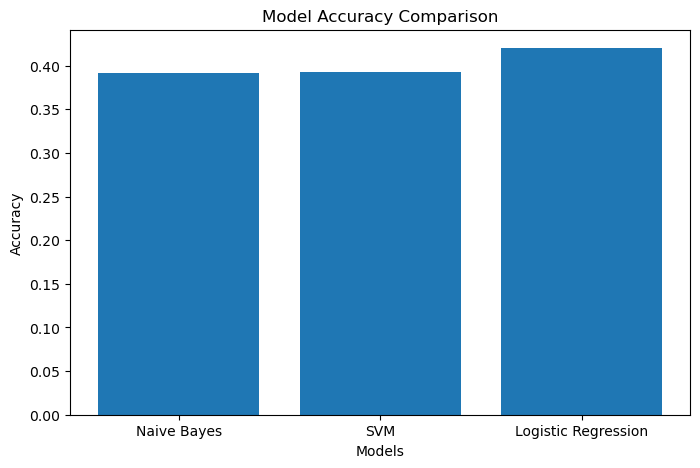

In [38]:
import matplotlib.pyplot as plt

models = ['Naive Bayes', 'SVM', 'Logistic Regression']
accuracies = [0.391045, 0.393284, 0.420149]

plt.figure(figsize=(8,5))
plt.bar(models, accuracies)

plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")

plt.show()

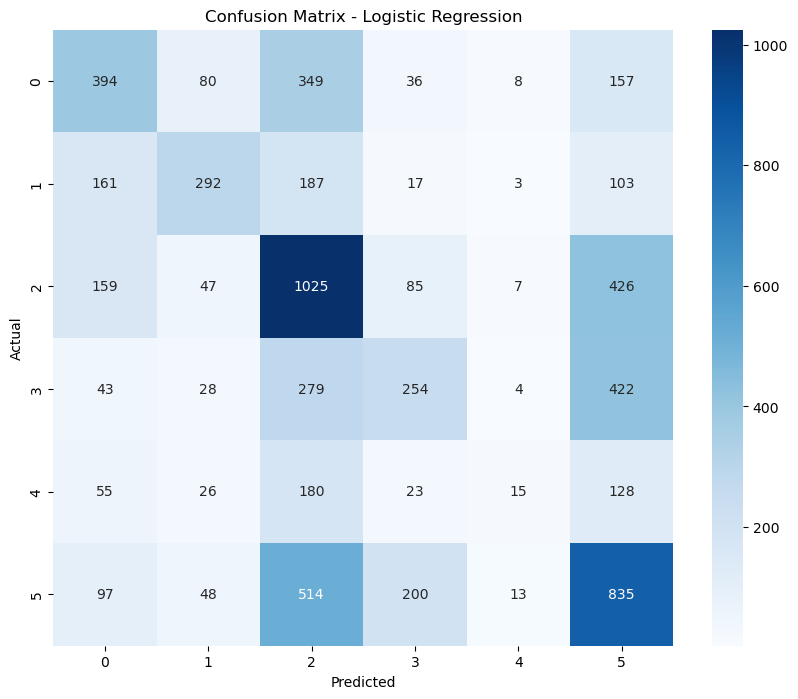

In [39]:
import seaborn as sns

cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(10,8))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [40]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.multiclass import OneVsRestClassifier

In [41]:
classes = y.unique()

y_bin = label_binarize(y, classes=classes)

X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    X,
    y_bin,
    test_size=0.2,
    random_state=42
)

In [42]:
model = OneVsRestClassifier(LogisticRegression(max_iter=1000))

model.fit(X_train_bin, y_train_bin)

y_score = model.predict_proba(X_test_bin)

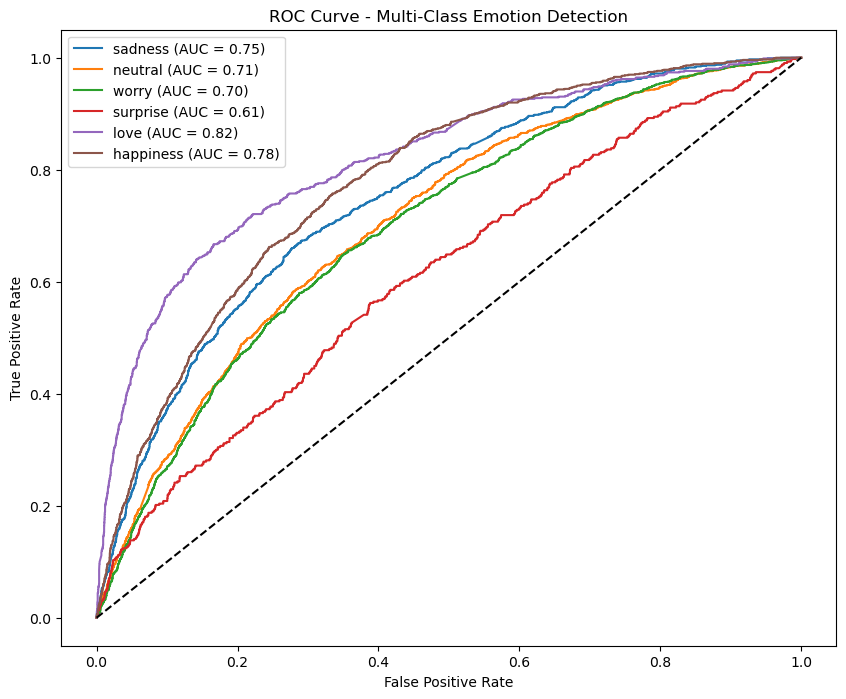

In [43]:
plt.figure(figsize=(10,8))

for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f'{classes[i]} (AUC = {roc_auc:.2f})')

plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Multi-Class Emotion Detection")

plt.legend()

plt.show()